In [ ]:
# Imported Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch.nn as nn
import pandas as pd
import numpy as np
import torch

In [ ]:
# Acces To Gdrive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Get Data File Into Variable
# Feature selection in time series modeling aims to create input tensors that are dense and relevant by removing static data that has no temporal patterns and deleting columns that are completely empty. This dimensional pruning is crucial to prevent overfitting and reduce the computational load on the model's weight matrices, especially when dealing with datasets that have a limited number of rows. By only keeping variables that logically have causal relationships, such as the number of tests, vaccination rate, and policy stringency index, we ensure that the backpropagation flow in the LSTM network can converge stably and produce accurate predictions.
df = pd.read_csv("IDN.csv")[['confirmed', 'tests', 'vaccines', 'stringency_index']]

# The Fifth In First In Data
df.head()

,confirmed,tests,vaccines,stringency_index
0,NaN,NaN,NaN,5.56
1,NaN,NaN,NaN,5.56
2,NaN,NaN,NaN,5.56
3,NaN,NaN,NaN,5.56
4,NaN,NaN,NaN,5.56


In [ ]:
# The Fifth In Last In Data
df.tail()

,confirmed,tests,vaccines,stringency_index
1416,NaN,NaN,NaN,NaN
1417,NaN,NaN,NaN,NaN
1418,NaN,NaN,NaN,NaN
1419,NaN,NaN,NaN,NaN
1420,NaN,NaN,448199860.0,NaN


In [ ]:
# Checking The Empty Data
df.isnull().sum()

,0
confirmed,318
tests,1050
vaccines,962
stringency_index,327


In [ ]:
# Checking The Duplicated Data
df.duplicated().sum()

np.int64(317)

In [ ]:
# Described Of Data
df.describe()

,confirmed,tests,vaccines,stringency_index
count,1.103000e+03,3.710000e+02,4.590000e+02,1094.000000
mean,3.347604e+06,2.732192e+07,1.698225e+08,58.750503
std,2.575479e+06,1.586686e+07,1.523782e+08,14.249390
min,2.000000e+00,7.781193e+06,0.000000e+00,5.560000
25%,5.536925e+05,1.216103e+07,2.560831e+07,50.000000
50%,4.123617e+06,2.374522e+07,1.215422e+08,62.500000
75%,6.057401e+06,4.036723e+07,3.344514e+08,71.760000
max,6.738225e+06,5.950374e+07,4.481999e+08,80.090000


In [ ]:
# Get Info The Value In Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1421 entries, 0 to 1420
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   confirmed         1103 non-null   float64
 1   tests             371 non-null    float64
 2   vaccines          459 non-null    float64
 3   stringency_index  1094 non-null   float64
dtypes: float64(4)
memory usage: 44.5 KB


In [ ]:
# The Replenish Empty Data

# Making The Value Of NAN Into 0
# We Select Column 'tests', 'vaccines' Because The Empty Data Its Just The Beginning Of Covid-19 Pandemic In Indonesian
df[['tests', 'vaccines']] = df[['tests', 'vaccines']].fillna(0)

# Making The Value Of NAN Into Value Between First And Last Data
# For metrics that run continuously but there are days when the government might report data late (creating 'gaps' in the middle), linear interpolation is the best method to connect the trend of the curve.
df[['confirmed', 'stringency_index']] = df[['confirmed', 'stringency_index']].interpolate(method='linear')

# Applying a safety net for remaining NaNs at the first or last rows
df[['confirmed', 'stringency_index']] = df[['confirmed', 'stringency_index']].bfill().ffill()

In [ ]:
# Terapkan diff() pada semua data yang bersifat kumulatif
kolom_kumulatif = ['confirmed', 'tests', 'vaccines']
df[kolom_kumulatif] = df[kolom_kumulatif].diff().fillna(0)

# Pastikan tidak ada angka minus akibat perbaikan data pemerintah
df[kolom_kumulatif] = df[kolom_kumulatif].clip(lower=0)

# Mengambil rata-rata 7 hari untuk meratakan lonjakan anomali pelaporan
df[kolom_kumulatif] = df[kolom_kumulatif].rolling(window=7, min_periods=1).mean()

In [ ]:
# Make Sure The Data Not Empty
df.isnull().sum()

,0
confirmed,0
tests,0
vaccines,0
stringency_index,0


In [ ]:
# Using `MinMaxScaler` is much more ideal than `StandardScaler` for LSTM modeling on COVID-19 data because its range (0 to 1) aligns with the network's activation functions, making it effective at preventing vanishing gradient issues. Plus, this method is perfect for exponential-type data (not normally distributed) and logically avoids producing negative numbers, which wouldn't make sense for real-world quantities like daily cases or total vaccinations.
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df)
# The Length Of Data Have Influence Into 'seq_length' In Function create_sequence
len(data_scaled)

1421

In [ ]:
# Making The Function create_seqeunce For X, y
# In time series modeling, the best predictor for guessing future numbers is the historical data of the metric itself. If you want to predict the number of COVID-19 cases on day 31, the most important variables the model needs to know are the number of cases on day 30, 29, and so on. The model needs to look at the trace of the target curve itself to identify whether the graph is rising exponentially or starting to flatten out.
def create_sequence(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        # Fetching data from day i to (i + seq_length - 1) for all 4 features
        X.append(data[i:(i + seq_length)])
        # Taking ONLY the 'confirmed' column (index 0) on the next day as the prediction target
        y.append(data[i + seq_length, 0])
    return np.array(X), np.array(y)

In [ ]:
# Use Funtion create_sequence
X, y = create_sequence(data_scaled, 30)
X = torch.Tensor(X)
y = torch.Tensor(y)

In [ ]:
# Split Data Into Train And Test With Note That Not Shuffle With It
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# `unsqueeze(1)` is used to add an extra dimension to the target tensor so that its shape changes from a 1D array (`[batch_size]`) to a 2D column matrix (`[batch_size, 1]`). This step is absolutely necessary because the prediction output coming from the last layer of your model (`nn.Linear`) will always have a 2D shape `[batch_size, 1]`. By matching the dimensions exactly between the target and the model's guess, we prevent errors or incorrect loss function (MSE) calculations due to PyTorch accidentally doing broadcasting (automatic dimension expansion) during backpropagation.
y_train = y_train.unsqueeze(1)
y_test = y_test.unsqueeze(1)

In [ ]:
# Let's Build The Model
class LuminaSequenceModel(nn.Module):
    def __init__(self, input_size=4, hidden_size=64, num_layers=2, output_size=1) -> None:
        super(LuminaSequenceModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        #LSTM layer: batch_first=True so that the tensor dimensions are (batch, seq, feature)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # Linear Layer (Fully Connected) to output 1 target prediction value
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialize the hidden and cell states (required at the start of each forward pass)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Feed data into the LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Take the memory from the last time-step (index -1)
        final_out = self.fc(out[:, -1, :])
        return final_out

In [ ]:
# Preparation Before Training Model
from torch.utils.data import TensorDataset, DataLoader

# Wrapping X_train and y_train into a DataLoader for mini-batching
train_dataset = TensorDataset(X_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Initialization of Model, Loss, and Optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LuminaSequenceModel().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Starts For Training The Model
epochs = 50

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_y in train_dataloader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # 1. Forward Pass: Model guessing the outcome
        prediction = model(batch_X)

        # 2. Calculate Error (Loss)
        loss = criterion(prediction, batch_y)
        total_loss += loss.item()

        # 3. Clean up the remaining gradients from the previous iteration.
        optimizer.zero_grad()

        # 4. Backward Pass (Opening the Backpropagation gate)
        loss.backward()

        # 5. Update the weight matrix based on the gradient direction
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        avg_loss = total_loss / len(train_dataloader)
        print(f"Epoch{epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

Epoch10/50, Loss: 0.000418
Epoch20/50, Loss: 0.000260
Epoch30/50, Loss: 0.000217
Epoch40/50, Loss: 0.000126
Epoch50/50, Loss: 0.000113


In [ ]:
# Pastikan X_test dan y_test sudah menjadi tensor dan berada di device yang sama
X_test_tensor = X_test.clone().detach().to(device) if isinstance(X_test, torch.Tensor) else torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = y_test.clone().detach().to(device) if isinstance(y_test, torch.Tensor) else torch.tensor(y_test, dtype=torch.float32).to(device)

# Tambahkan dimensi ekstra ke y_test jika belum ada
if len(y_test_tensor.shape) == 1:
    y_test_tensor = y_test_tensor.unsqueeze(1)

# 1. Pindah ke mode evaluasi
model.eval()

# 2. Matikan aliran gradien
with torch.no_grad():
    test_predictions = model(X_test_tensor)
    test_loss = criterion(test_predictions, y_test_tensor)

print(f"Loss pada Data Uji (MSE): {test_loss.item():.6f}")

Loss pada Data Uji (MSE): 0.000042


In [ ]:
import numpy as np

# Pindahkan data kembali ke CPU (jika pakai GPU) dan ubah ke NumPy array
preds_numpy = test_predictions.cpu().numpy()
actuals_numpy = y_test_tensor.cpu().numpy()

# Membuat matriks kosong dengan 4 kolom (menyesuaikan jumlah fitur asli)
dummy_preds = np.zeros((len(preds_numpy), 4))
dummy_actuals = np.zeros((len(actuals_numpy), 4))

# Masukkan tebakan dan data asli ke kolom pertama (indeks 0 -> 'confirmed')
dummy_preds[:, 0] = preds_numpy[:, 0]
dummy_actuals[:, 0] = actuals_numpy[:, 0]

# Lakukan Inverse Transform dan ambil KEMBALI HANYA kolom pertama
prediksi_asli = scaler.inverse_transform(dummy_preds)[:, 0]
target_asli = scaler.inverse_transform(dummy_actuals)[:, 0]

# Memaksa tebakan yang bernilai minus (negatif) menjadi tepat 0
prediksi_asli = np.clip(prediksi_asli, a_min=0, a_max=None)

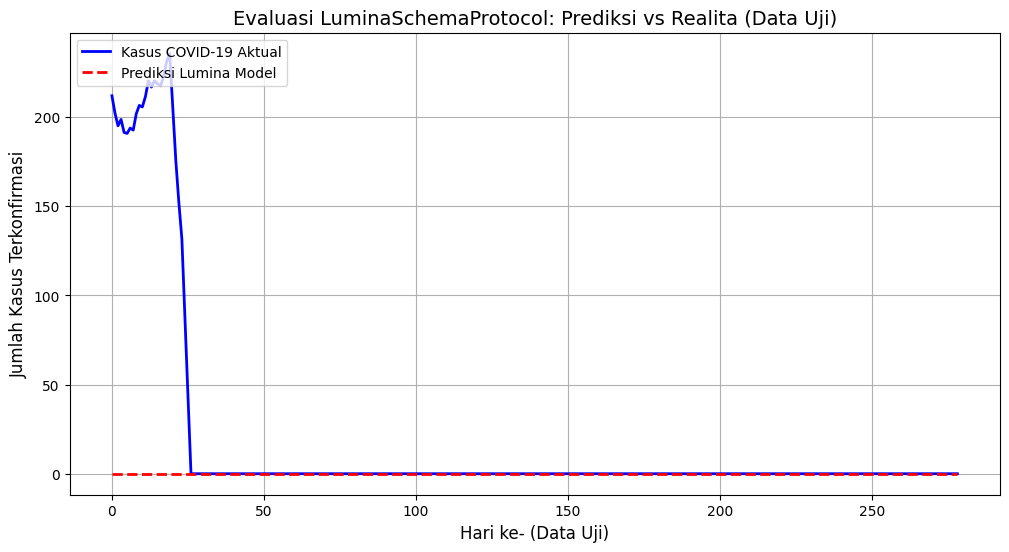

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot data asli (Target)
plt.plot(target_asli, label='Kasus COVID-19 Aktual', color='blue', linewidth=2)

# Plot data tebakan (Prediksi)
plt.plot(prediksi_asli, label='Prediksi Lumina Model', color='red', linestyle='dashed', linewidth=2)

plt.title('Evaluasi LuminaSchemaProtocol: Prediksi vs Realita (Data Uji)', fontsize=14)
plt.xlabel('Hari ke- (Data Uji)', fontsize=12)
plt.ylabel('Jumlah Kasus Terkonfirmasi', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True)
plt.show()